In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams.update({
    'text.latex.preamble': r'\usepackage{amsfonts}'
})


## Estimating position information in symmetry-broken Ising

In [7]:
from scipy.special import xlogy

def get_transfer_matrix(J, h):
    """
    Get the transfer matrix for the Ising model with given J and h.
    """
    return np.array([[np.exp(J + h), np.exp(-J)],
                     [np.exp(-J), np.exp(J - h)]])

def get_partition_function(J, h, N):
    """
    Calculate the partition function for the broken-symmetry Ising model.
    """
    T1 = get_transfer_matrix(J,h)
    T0 = get_transfer_matrix(J,0.)
    T_N = np.linalg.matrix_power(T0, N//2-1)
    T2 = get_transfer_matrix(J,-h)
    T = T1 @ T_N @ T2 @ T_N
    return np.trace(T)

def get_marginals(J, h, N):
    """
     Calculate the marginal probability for the i-th spin in the broken-symmetry Ising model.
     """
    
    Z = get_partition_function(J, h, N)

    T1 = get_transfer_matrix(J,h)
    T0 = get_transfer_matrix(J,0.)
    T2 = get_transfer_matrix(J,-h)

    sZ = np.array([[1, 0],[0,0]])

    T_N = np.linalg.matrix_power(T0, N//2-1)
    ps = np.zeros(N)
    ps[0] =  np.trace(sZ @  T1 @ T_N @ T2 @ T_N)
    ps[N//2] = np.trace(T1 @ T_N @ sZ @ T2 @ T_N)
    for i in range(0, N//2):
        block_T  = np.linalg.matrix_power(T0,i) @ sZ @ np.linalg.matrix_power(T0, N//2-i-1)
        ps[i] = np.trace(T1 @  block_T @ T2 @ T_N ) 
        ps[N//2 + i] = np.trace(T1 @ T_N @ T2 @  block_T )
    return ps / Z

def normcheck(J, h, N):
    """
     Calculate the marginal probability for the i-th spin in the broken-symmetry Ising model.
     """
    
    Z = get_partition_function(J, h, N)

    T1 = get_transfer_matrix(J,h)
    T0 = get_transfer_matrix(J,0.)
    T2 = get_transfer_matrix(J,-h)

    sZ = np.array([[1, 0],[0,1]])

    T_N = np.linalg.matrix_power(T0, N//2-1)
    ps = np.zeros(N)
    ps[0] =  np.trace(sZ @  T1 @ T_N @ T2 @ T_N)
    ps[N//2] = np.trace(T1 @ T_N @ sZ @ T2 @ T_N)
    for i in range(0, N//2):
        block_T  = np.linalg.matrix_power(T0,i) @ sZ @ np.linalg.matrix_power(T0, N//2-i-1)
        ps[i] = np.trace(T1 @  block_T @ T2 @ T_N ) 
        ps[N//2 + i] = np.trace(T1 @ T_N @ T2 @  block_T )
    return ps / Z

def get_meanvals(J, h, N):
    """
     Calculate the marginal probability for the i-th spin in the broken-symmetry Ising model.
     """
    
    Z = get_partition_function(J, h, N)

    T1 = get_transfer_matrix(J,h)
    T0 = get_transfer_matrix(J,0.)
    TN2 = get_transfer_matrix(J,-h)

    sZ = np.array([[1, 0],[0,-1]])

    T_N = np.linalg.matrix_power(T0, N//2-1)
    ps = np.zeros(N)
    ps[0] =  np.trace(sZ @  T1 @ T_N @ TN2 @ T_N)
    ps[N//2] = np.trace(T1 @ T_N @ sZ @ TN2 @ T_N)
    for i in range(0, N//2):
        block_T  = np.linalg.matrix_power(T0,i) @ sZ @ np.linalg.matrix_power(T0, N//2-i-1)
        ps[i] = np.trace(T1 @  block_T @ TN2 @ T_N )
        ps[N//2 + i] = np.trace(T1 @ T_N @ TN2 @  block_T )
    return ps /Z

def get_positionalInfo(ps,N):
    """
    Calculate the positional information for the i-th spin in the broken-symmetry Ising model.
    """
    pooled_p = np.mean(ps)
    pooled_m = np.mean(1-ps)

    pos_info = np.zeros(N)
    for i in range(0, N):
        #pos_info[i] = ps[i] * np.log(ps[i]/pooled_p) + (1-ps[i]) * np.log((1-ps[i])/pooled_m)
        pos_info[i] = xlogy(ps[i], ps[i]/pooled_p)  + xlogy(1-ps[i], (1-ps[i])/pooled_m)
    return np.mean(pos_info) / np.log(2)


In [8]:
# quick test run

J = 0.3
h = 3
N = 32

ps = get_marginals(J, h, N)
means = get_meanvals(J, h, N)
norms = normcheck(J, h, N)

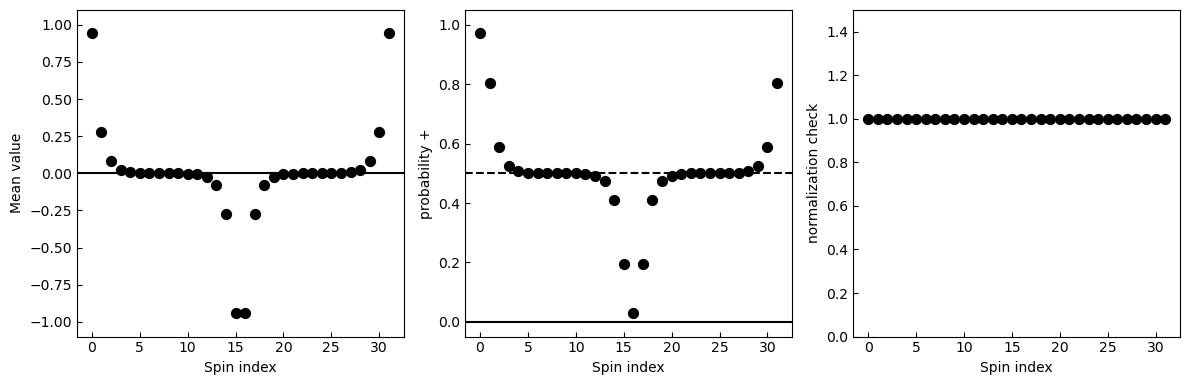

In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(np.arange(N), means, s=50, c='k', marker='o')
plt.xlabel('Spin index')
plt.ylabel('Mean value')
plt.axhline(0, color='k')
plt.ylim(-1.1,1.1)
plt.gca().set_box_aspect(1)

plt.subplot(1,3,2)
plt.scatter(np.arange(N), 0.5*(ps + np.roll(ps,1)), s=50, c='k', marker='o')
plt.xlabel('Spin index')
plt.ylabel('probability +')
plt.axhline(0, color='k')
plt.axhline(0.5, color='k', linestyle='--')
plt.ylim(-0.05, 1.05)
plt.gca().set_box_aspect(1)

plt.subplot(1,3,3)
plt.scatter(np.arange(N), norms, s=50, c='k', marker='o')
plt.xlabel('Spin index')
plt.ylabel('normalization check')
plt.ylim(0,1.5)
plt.gca().set_box_aspect(1)

plt.tight_layout()

Text(0, 0.5, 'Marginal probability')

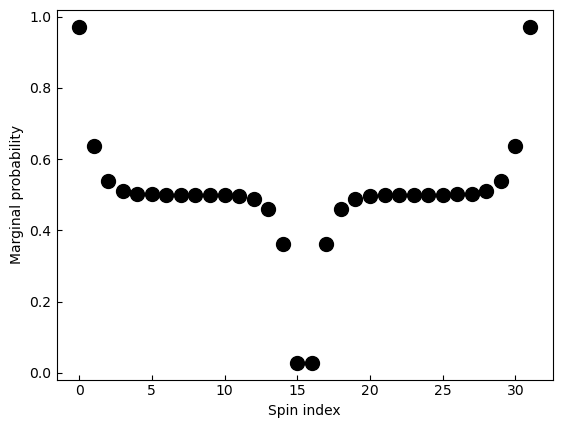

In [10]:
plt.figure()
plt.scatter(np.arange(N), ps, s=100, c='k', marker='o')
plt.xlabel('Spin index')
plt.ylabel('Marginal probability')

First run - sweep coupling strength $J$ at constant $h$

In [49]:
N_J = 50
Js = np.logspace(-2,np.log10(10),N_J)

entropies = np.zeros(N_J)
for i, J in enumerate(Js):
    h = 3
    N = 32
    ps = get_marginals(J, h, N)
    entropies[i] = get_positionalInfo(ps, N)

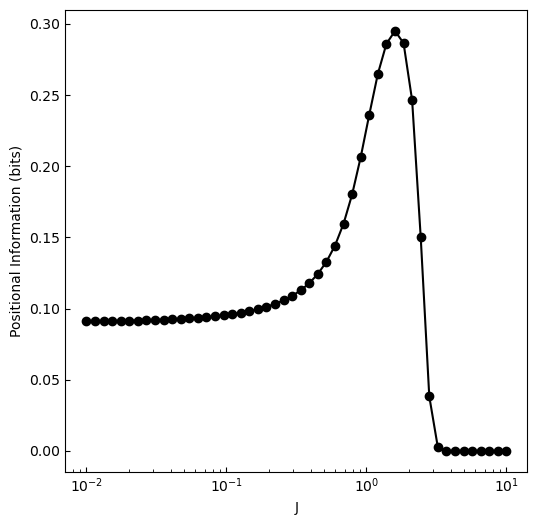

In [50]:
plt.figure(figsize=(8, 6))
plt.plot(Js, entropies, marker='o', linestyle='-', color='k')
plt.xlabel('J')
plt.xscale('log')
plt.ylabel('Positional Information (bits)')
plt.gca().set_box_aspect(1)

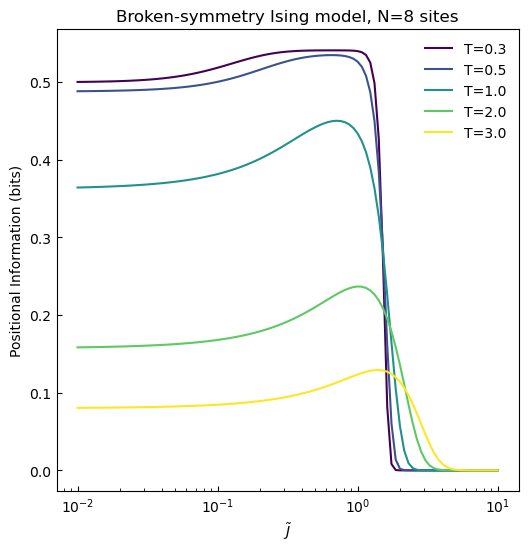

In [51]:
N_J = 100

Ts = [0.3, 0.5, 1.0, 2.0, 3.0]
colr = plt.cm.viridis(np.linspace(0, 1, len(Ts)))
plt.figure(figsize=(8, 6))

for j, T in enumerate(Ts):
    Js = np.logspace(-2,np.log10(10),N_J)

    entropies = np.zeros(N_J)
    for i, J in enumerate(Js):
        h = 3 / T
        N = 8
        ps = get_marginals(J/T, h, N)
        #ps_bond = 0.5*(ps + np.roll(ps,1))
        entropies[i] = get_positionalInfo(ps, N)
    plt.plot(Js, entropies, linestyle='-', color=colr[j], label=f'T={T}')
plt.xlabel(r'$\tilde{J}$')
plt.xscale('log')
plt.ylabel('Positional Information (bits)')
plt.title('Broken-symmetry Ising model, N=8 sites')
plt.legend(frameon=False)
plt.gca().set_box_aspect(1)

/opt/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:1904: RuntimeWarning: overflow encountered in reduce
  return asanyarray(a).trace(
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:100: RuntimeWarning: invalid value encountered in scalar divide
  pos_info[i] = xlogy(ps[i], ps[i]/pooled_p)  + xlogy(1-ps[i], (1-ps[i])/pooled_m)
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:18: RuntimeWarning: overflow encountered in matmul
  T = T1 @ T_N @ T2 @ T_N
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:36: RuntimeWarning: overflow encountered in matmul
  ps[0] =  np.trace(sZ @  T1 @ T_N @ T2 @ T_N)
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:37: RuntimeWarning: overflow encountered in matmul
  ps[N//2] = np.trace(T1 @ T_N @ sZ @ T2 @ T_N)
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:40: RuntimeWarning: ove

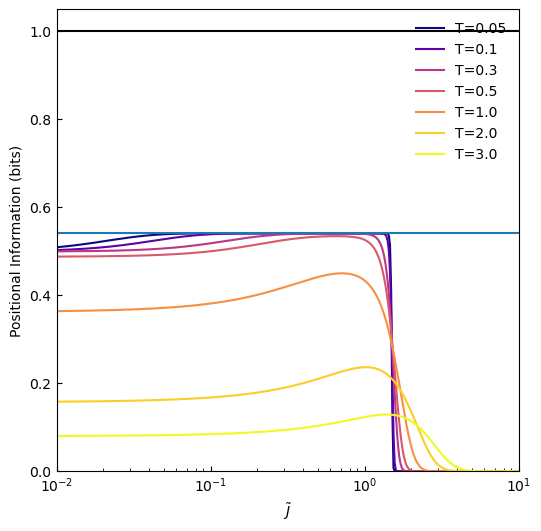

In [52]:
N_J = 400
Js = np.logspace(-2,np.log10(10),N_J)

entropies = np.zeros(N_J)
for i, J in enumerate(Js):
    h = 3
    N = 32
    ps = get_marginals(J, h, N)
    entropies[i] = get_positionalInfo(ps, N)

Ts = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0]
colr = plt.cm.viridis(np.linspace(0, 1, len(Ts)))
plt.figure(figsize=(8, 6))
import matplotlib as mpl 


norm = mpl.colors.LogNorm(vmin=0.05, vmax=3.0)
scalarMap = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.plasma)

for j, T in enumerate(Ts):
    Js = np.logspace(-2,np.log10(10),N_J)

    entropies = np.zeros(N_J)
    for i, J in enumerate(Js):
        h = 3 / T
        N = 8
        ps = get_marginals(J/T, h, N)
        entropies[i] = get_positionalInfo(ps, N)
    plt.plot(Js, entropies, linestyle='-', color=scalarMap.to_rgba(T), label=f'T={T}')
plt.xlabel('$\\tilde{J}$')
plt.xlim(1e-2, 10)
plt.ylim(0, 1.05)
plt.axhline(1, color='k')
p_ = np.hstack([np.linspace(0,1,N//2), np.linspace(1,0,N//2), np.linspace(0,1,N//2), np.linspace(1,0,N//2) ])

s = 1/(2*N) *np.sum( xlogy(p_, p_) + xlogy(1-p_, 1-p_))/np.log(2)


plt.axhline(1+s)

plt.xscale('log')
plt.ylabel('Positional Information (bits)')
plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
#plt.savefig('ising_PI_D_varT_N8_h3.pdf')

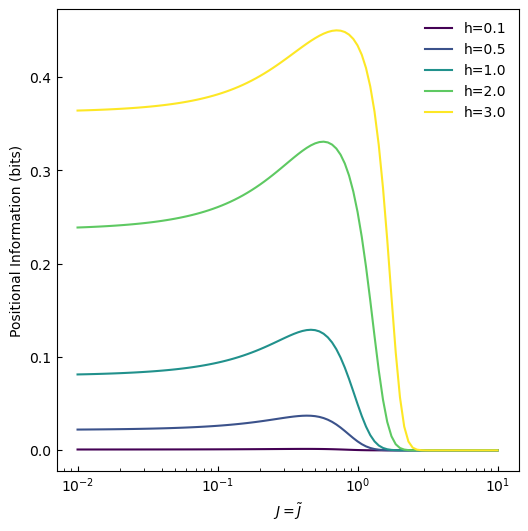

In [53]:
# variable h at fixed T=1
N_J = 100
hs = [0.1, 0.5, 1.0, 2.0, 3.0]
colr = plt.cm.viridis(np.linspace(0, 1, len(hs)))
plt.figure(figsize=(8, 6))
T = 1
for j, h in enumerate(hs):
    Js = np.logspace(-2,np.log10(10),N_J)

    entropies = np.zeros(N_J)
    for i, J in enumerate(Js):
        #h = h / T
        N = 8
        ps = get_marginals(J/T, h, N)
        entropies[i] = get_positionalInfo(ps, N)
    plt.plot(Js, entropies, linestyle='-', color=colr[j], label=f'h={h}')
plt.xlabel(r'$J=\tilde{J}$')
plt.xscale('log')
plt.ylabel('Positional Information (bits)')
plt.legend(frameon=False)
plt.gca().set_box_aspect(1)


### Marginals as a function of $J$

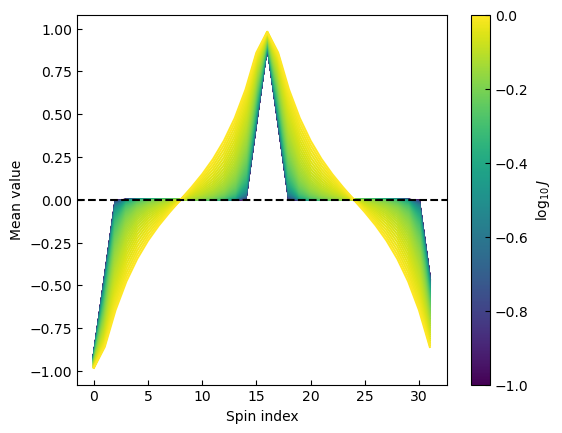

In [54]:
plt.figure()

Js = np.logspace(-2,np.log10(1),N_J)
colors = plt.cm.viridis(np.linspace(0, 1, len(Js)))
for i, J in enumerate(Js):
    h = 3
    N = 32
    ps = get_marginals(J, h, N)
    plt.plot(np.arange(N), 1-2*(0.5*(ps+np.roll(ps,1))), color=colors[i])
plt.axhline(0, color='k', linestyle='--')
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=-1, vmax=0)
plt.xlabel('Spin index')
plt.ylabel('Mean value')
plt.gca().set_box_aspect(1)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), ax=plt.gca(), label=r'$\log_{10}J$')

In [55]:
def periodize(x, k):
    N = len(x)
    rolled = np.roll(x,k)
    per = np.zeros(N+2)
    per[1:-1] = rolled[:]
    per[0] = rolled[-1]
    per[-1] = rolled[0]
    return per

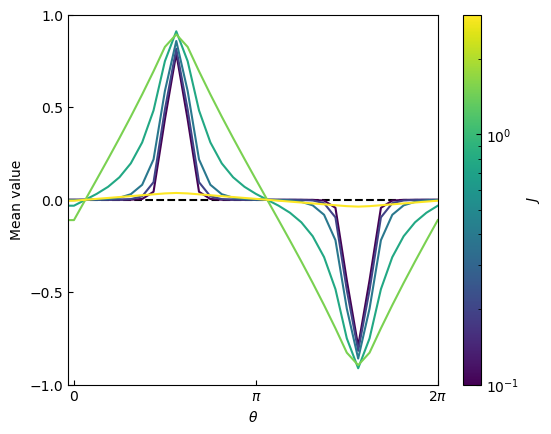

In [56]:
plt.figure()

N_J = 6
Js = np.logspace(-1,np.log10(3.),N_J)
colors = plt.cm.viridis(np.linspace(0, 1, len(Js)))
for i, J in enumerate(Js):
    h = 2
    N = 32
    ps = get_marginals(J, h, N)
    ps = periodize(ps, -7)
    plt.plot(2*np.pi*np.arange(-1,N+1)/(N+0), 1-2*0.5*(ps+np.roll(ps,1)), color=colors[i])
plt.axhline(0, color='k', linestyle='--', zorder=-1)
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=np.min(Js), vmax=np.max(Js))

plt.xlabel('$\\theta$')
plt.ylabel('Mean value')
plt.gca().set_box_aspect(1)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), ax=plt.gca(), label=r'$J$')

plt.ylim(-1, 1)
plt.xticks(ticks=[0, np.pi, 2*np.pi], labels=['$0$', '$\\pi$', '$2\\pi$'])
plt.yticks(ticks=[-1, -0.5, 0, 0.5, 1])
plt.xlim(0-.1, 2*np.pi)

plt.savefig('ising_mean_vs_pos.pdf')

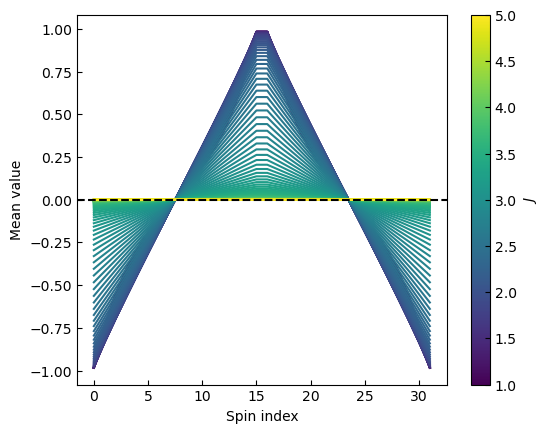

In [57]:
# linear sweep of J in [1,5] - showing flattening of marginals

plt.figure()

N_J = 100
Js = np.linspace(1, 5, N_J)
colors = plt.cm.viridis(np.linspace(0, 1, len(Js)))
for i, J in enumerate(Js):
    h = 3
    N = 32
    ps = get_marginals(J, h, N)
    plt.plot(np.arange(N), 1-2*ps, color=colors[i])
plt.axhline(0, color='k', linestyle='--')
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=1, vmax=5)
plt.xlabel('Spin index')
plt.ylabel('Mean value')
plt.gca().set_box_aspect(1)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), ax=plt.gca(), label=r'$J$')

A gif of marginals as $J$ is changed

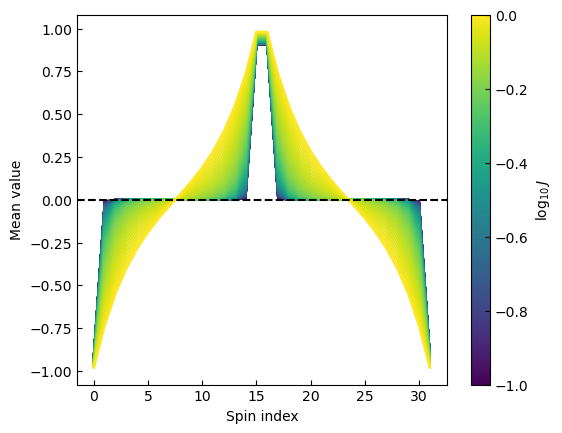

In [58]:
# make video of marginals

plt.figure()

Js = np.logspace(-2,np.log10(1),N_J)
colors = plt.cm.viridis(np.linspace(0, 1, len(Js)))
for i, J in enumerate(Js):
    h = 3
    N = 32
    ps = get_marginals(J, h, N)
    plt.plot(np.arange(N), 1-2*ps, color=colors[i])
plt.axhline(0, color='k', linestyle='--')
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=-1, vmax=0)
plt.xlabel('Spin index')
plt.ylabel('Mean value')
plt.gca().set_box_aspect(1)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis), ax=plt.gca(), label=r'$\log_{10}J$')

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import imageio


def generate_gif(Js, h, N, filename='marginals.gif'):
    images = []
    for J in Js:
        ps = get_marginals(J, h, N)
        plt.figure()
        plt.plot(np.arange(N), 1 - 2 * ps, color='k')
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel('Spin index')
        plt.ylabel('Mean value')
        plt.title(f'Marginal Probabilities for J={J:.2f}')
        plt.ylim(-1.1, 1.1)
        
        # Save the current plot to a temporary file
        plt.savefig('temp_plot.png')
        plt.close()
        
        # Read the saved plot and append it to the images list
        images.append(imageio.imread('temp_plot.png'))
    
    # Create a GIF from the images
    imageio.mimsave(filename, images, duration=0.5, loop=0)  # duration in seconds per frame

N_J = 50
Js = np.logspace(-2, np.log10(3), N_J)
h = 3
N = 32
generate_gif(Js, h, N)

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/142988442.py:23: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_plot.png'))


### PI saturation for variable $N$

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/2793665374.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


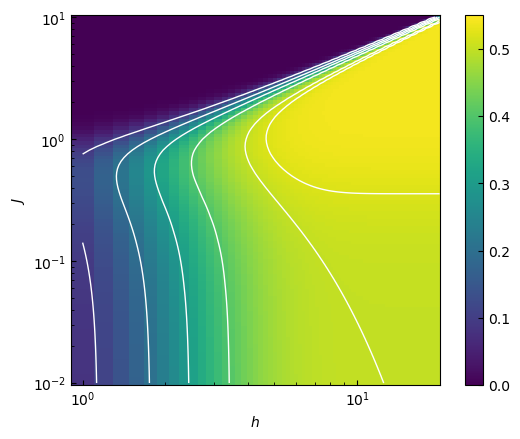

In [60]:
# N = 8 contour plot of PI vs J and h
N_J = 100
N_h = 100
Hs = np.linspace(1, 20, N_h)
entropies_arr = np.zeros((N_J, N_h))
plt.figure()
for j, h in enumerate(Hs):
    Js = np.logspace(-2,np.log10(10),N_J)
    for i, J in enumerate(Js):
        N = 8
        ps = get_marginals(J, h, N)
        entropies_arr[i,j] = get_positionalInfo(ps, N)
plt.pcolormesh(Hs, Js, entropies_arr[:,:],  shading='nearest', cmap='viridis', vmin=0, vmax =0.55)
plt.colorbar()
plt.contour(Hs, Js, entropies_arr[:,:], levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.52], colors='w', linewidths=1)
plt.xlabel('$h$')
plt.ylabel('$J$')

plt.yscale('log')
plt.xscale('log')

#plt.ylabel('Positional Information (bits)')
plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
plt.savefig('Ising_PI_Dvh_N8_contour.pdf')

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/2699024061.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


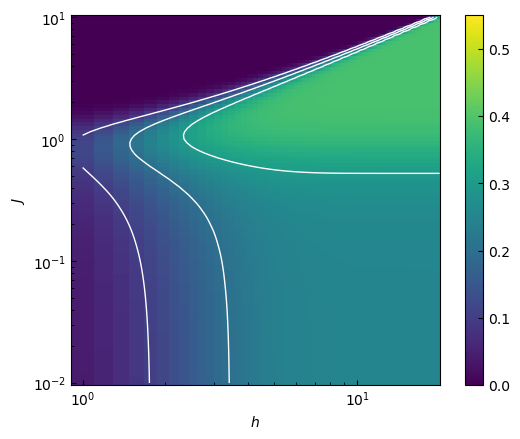

In [61]:
# N = 16
N_J = 100
N_h = 100
Hs = np.linspace(1, 20, N_h)
entropies_arr = np.zeros((N_J, N_h))
for j, h in enumerate(Hs):
    Js = np.logspace(-2,np.log10(10),N_J)
    for i, J in enumerate(Js):
        N = 16
        ps = get_marginals(J, h, N)
        entropies_arr[i,j] = get_positionalInfo(ps, N)
plt.figure()
plt.pcolormesh(Hs, Js, entropies_arr[:,:],  shading='nearest', cmap='viridis', vmin=0, vmax =0.55)
plt.colorbar()
plt.contour(Hs, Js, entropies_arr[:,:], levels=[0.1, 0.2, 0.3, 0.4], colors='w', linewidths=1)
plt.xlabel('$h$')
plt.ylabel('$J$')

plt.yscale('log')
plt.xscale('log')

plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
plt.savefig('Ising_PI_Dvh_N32_contour.pdf')

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/447530135.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


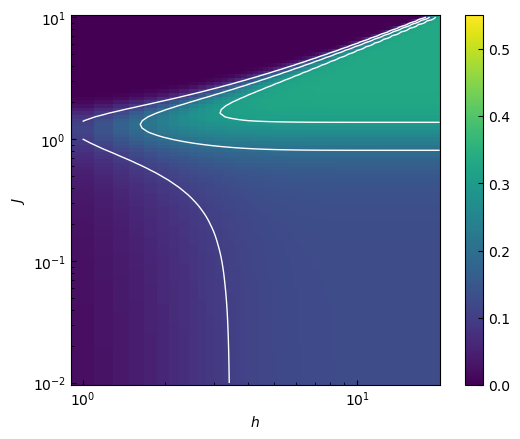

In [62]:
# N = 32 
N_J = 100
N_h = 100
Hs = np.linspace(1, 20, N_h)
entropies_arr = np.zeros((N_J, N_h))
for j, h in enumerate(Hs):
    Js = np.logspace(-2,np.log10(10),N_J)
    for i, J in enumerate(Js):
        N = 32
        ps = get_marginals(J, h, N)
        entropies_arr[i,j] = get_positionalInfo(ps, N)
plt.figure()
plt.pcolormesh(Hs, Js, entropies_arr[:,:],  shading='nearest', cmap='viridis', vmin=0, vmax =0.55)
plt.colorbar()
plt.contour(Hs, Js, entropies_arr[:,:], levels=[0.1, 0.2, 0.3], colors='w', linewidths=1)
plt.xlabel('$h$')
plt.ylabel('$J$')

plt.yscale('log')
plt.xscale('log')

plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
plt.savefig('Ising_PI_Dvh_N32_contour.pdf')

In [63]:
# compute maximal positional information vs N
Ns = np.arange(2, 80,2)
maxes_PI = np.zeros(len(Ns))
N_J = 40
N_h = 40
Js = np.logspace(-1,np.log10(1000),N_J)
Hs = np.linspace(0, 30, N_h)

for k, n in enumerate(Ns):
    entropies_arr = np.zeros((N_J, N_h))
    for j, h in enumerate(Hs):
        Js = np.logspace(-2,np.log10(10),N_J)
        for i, J in enumerate(Js):
            N = n
            ps = get_marginals(J, h, N)
            entropies_arr[i,j] = get_positionalInfo(ps, N)
    m_PI = np.max(entropies_arr[np.logical_not(np.isnan(entropies_arr))])
    print(m_PI)
    maxes_PI[k] = np.max(entropies_arr)

1.2012849389305942e-16
0.9999999999958168
0.666666666665241
0.5408520829719214
0.47548875021568127
0.43570710355195147
0.4090519269411801
0.38999462920327893
0.37571631764741176
0.36463305296411375
0.3557881486974371
0.3485705207895984
0.342572001981786
0.3375098153387335
0.3331819965659261
0.32944053263813367
0.3261745249235145
0.32329927437615175
0.32074899690162845
0.3184718364103139
0.31642637354114633
0.3145791324088552
0.3129027681546305
0.31137472817366324
0.30997624882874936
0.3086915936386185
0.3075074678446671
0.30641256354925905
0.30539720271337983
0.3044530543338392
0.3035729084430167
0.3027504940606063
0.3019803314506511


/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:18: RuntimeWarning: overflow encountered in matmul
  T = T1 @ T_N @ T2 @ T_N
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:36: RuntimeWarning: overflow encountered in matmul
  ps[0] =  np.trace(sZ @  T1 @ T_N @ T2 @ T_N)
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:40: RuntimeWarning: overflow encountered in matmul
  ps[i] = np.trace(T1 @  block_T @ T2 @ T_N )


0.3012576113808783


/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:41: RuntimeWarning: overflow encountered in matmul
  ps[N//2 + i] = np.trace(T1 @ T_N @ T2 @  block_T )
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:42: RuntimeWarning: invalid value encountered in divide
  return ps / Z
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/576693486.py:37: RuntimeWarning: overflow encountered in matmul
  ps[N//2] = np.trace(T1 @ T_N @ sZ @ T2 @ T_N)


0.3005780958038934
0.2999380356587367
0.2993341024499493
0.29876333098628005
0.29822307121410824


0 0.0
1.0
1 -0.3333333333333333
0.6666666666666667
2 -0.4591479170272447
0.5408520829727552
3 -0.5245112497836532
0.47548875021634684
4 -0.5642928964473437
0.4357071035526563
5 -0.5909480730579554
0.4090519269420446
6 -0.6100053707958025
0.3899946292041975
7 -0.624283682351932
0.375716317648068
8 -0.6353669470353958
0.36463305296460424
9 -0.6442118513021827
0.3557881486978173
10 -0.6514294792100979
0.34857052078990214
11 -0.6574279980179638
0.3425720019820362
12 -0.6624901846610567
0.3375098153389433
13 -0.666818003433893
0.33318199656610703
14 -0.6705594673617064
0.32944053263829365
15 -0.6738254750763422
0.32617452492365784
16 -0.676700725623717
0.32329927437628303
17 -0.6792510030982488
0.3207489969017512
18 -0.68152816358957
0.31847183641043
19 -0.6835736264587422
0.3164263735412578
20 -0.6854208675910366
0.3145791324089634
21 -0.6870972318452628
0.31290276815473717
22 -0.6886252718262301
0.3113747281737699
23 -0.6900237511711437
0.3099762488288563
24 -0.6913084063612729
0.30869159

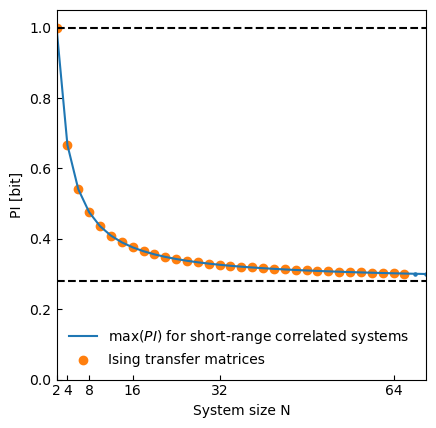

In [64]:
from scipy.special import xlogy

## plot theoretical bound and observed value vs N
plt.figure()
Ns = np.arange(2, 100)
bound_n = np.ones(len(Ns))
for i,n in enumerate(Ns):
    p_ = np.linspace(0,1,n)
    s = 1/(n) *np.sum( xlogy(p_, p_) + xlogy(1-p_, 1-p_))/np.log(2)
    print(i,s)
    print(1+s)
    bound_n[i] = 1+s

plt.plot(2*Ns-2, bound_n, label='$\\max(PI)$ for short-range correlated systems') # -2 because of how the external field is applied on the bonds
plt.scatter(2*Ns-2, bound_n, 5)
plt.scatter(np.arange(2, 80,2)[1:]-2, maxes_PI[1:], label='Ising transfer matrices')
plt.axhline(1-0.5/np.log(2), color='k', linestyle='--')
plt.axhline(1, color='k', linestyle='--')

plt.legend(frameon=False)
plt.xticks([2, 4, 8, 16, 32, 64], [2, 4, 8, 16, 32, 64])
x = np.linspace(2, 100)


plt.xlabel('System size N')
plt.ylabel('PI [bit]')
plt.xlim(left=2, right=70)#np.max(Ns) )
plt.ylim(0, 1.05)

plt.gca().set_box_aspect(1)

# Potts model

In [65]:
q = 3

N = 8

from scipy.special import xlogy

def get_transfer_matrix_Potts(J, hs, q=2):
    """
    Get the transfer matrix for the Potts model with q values, with given J and (q,) vector  of h.
    """
    mat = np.outer(np.exp(0.5*hs), np.exp(0.5*hs))
    np.fill_diagonal(mat, np.exp(J+hs))
    return mat

def get_partition_function_Potts(J, h, q, M):
    """
    Calculate the partition function for the broken-symmetry q-Potts model.
    """
    hq = np.zeros((q+1,q))
    for i in range(q):
        hq[i+1,i] = h

    T0 = get_transfer_matrix_Potts(J,hq[0,:])
    T_N = np.linalg.matrix_power(T0, M-1)
    Tqs = [get_transfer_matrix_Potts(J,hq[i,:],q=q) for i in range(1,q+1)]
    T = np.eye(q)
    for i in range(0,q):
        T = T @ Tqs[i] @ T_N
    return np.trace(T)

def get_marginals_Potts(J, h, M, q):
    """
     Calculate the marginal probability for the i-th spin in the broken-symmetry q-Potts model.
     """
    
    Z = get_partition_function_Potts(J, h, q, M)

    hq = np.zeros((q+1,q))
    for i in range(q):
        hq[i+1,i] = h

    T0 = get_transfer_matrix_Potts(J,hq[0,:])
    T_M = np.linalg.matrix_power(T0, M-1)
    # transfer matrices where there is a non-field external field
    Tqs = [get_transfer_matrix_Potts(J,hq[i,:],q=q) for i in range(1,q+1)]
    T = np.eye(q)
    for i in range(0,q):
        T = T @ Tqs[i] @ T_M

    # construct projection operators
    sQ = [np.zeros((q,q)) for _ in range(q)]
    for i in range(q):
        sQ[i][i,i] = 1

    # construct the marginals:
    # build the matrix product (in the right order!) and
    # loop over position and states and compute tra
    ps = np.zeros((q*M,q))
    for n in range(q): # for each state
        for k in range(q): # for each position where fields acts
            T = np.eye(q)
            for i in range(0,q):
                if i == k:
                    T = T @ sQ[n] @ Tqs[i] @ T_M
                else:
                    T = T @ Tqs[i] @ T_M
            ps[k*M,n] = np.trace(T) / Z # the marginal at the k-th position in the block for state n
        for i in range(1, M): # for other positions
            if i % M != 0:
                block_T = np.linalg.matrix_power(T0,i) @ sQ[n] @ np.linalg.matrix_power(T0, M-i-1)
                for k in range(q):
                    T = np.eye(q)
                    for j in range(0,q):
                        if j == k:
                            T = T @  Tqs[j] @ block_T
                        else:
                            T = T @ Tqs[j] @ T_M
                    ps[i + k*M,n] = np.trace(T) / Z
    return ps

def get_positionalInfo_Potts(ps,M, q):
    """
    Calculate the positional information for the i-th spin in the q-Potts model.
    """
    pooled_z = np.mean(ps,axis=0)
    N = M*q
    pos_info = np.zeros(M*q)
    for i in range(0, N):
        pos_info[i] = np.sum(xlogy(ps[i,:], ps[i,:]/pooled_z))
    return np.mean(pos_info) / np.log(2)


In [66]:
# quick test run for q-Potts model, q = 5
J = 3
h = 3
M = 32
q = 5

ps = get_marginals_Potts(J, h, M, q)

Text(0.5, 0, 'Spin index')

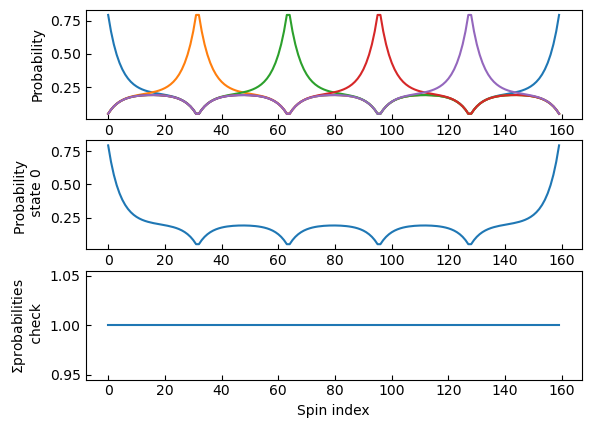

In [79]:
# marginals 
plt.figure()
plt.subplot(3,1,1)
plt.plot(np.arange(q*M), ps)
plt.ylabel('Probability')

plt.subplot(3,1,2)
plt.plot(np.arange(q*M), ps[:,0])
plt.ylabel('Probability \n state 0')

plt.subplot(3,1,3)
plt.plot(np.arange(q*M), np.sum(ps,axis=1))
plt.ylabel('$\\Sigma$probabilities \n check')
plt.xlabel('Spin index')

#plt.tight_layout()

Text(0, 0.5, 'State index')

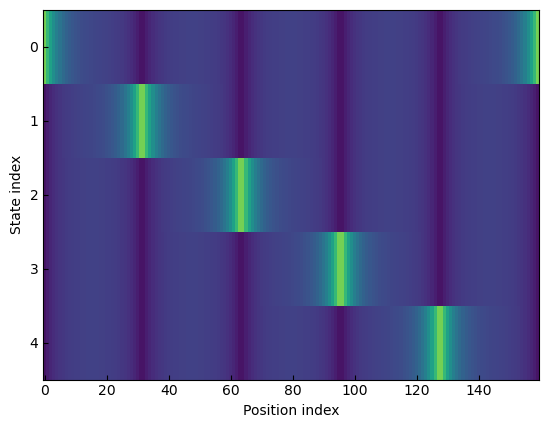

In [80]:
plt.figure()
plt.imshow(ps.T, aspect='auto', vmin=0, vmax=1)
plt.xlabel('Position index')
plt.ylabel('State index')


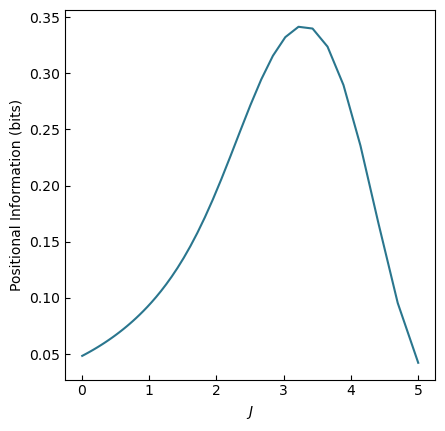

In [83]:
N_J = 100
Js = np.logspace(-2,np.log10(5),N_J)

q = 3
colr = plt.cm.viridis(np.linspace(0,1,N_J))
entropies = np.zeros(N_J)
for i, J in enumerate(Js):
    h = 3
    M = 16
    ps = get_marginals_Potts(J, h, M, q)
    entropies[i] = get_positionalInfo_Potts(ps, M, q)
plt.plot(Js, entropies, linestyle='-', color=colr[j], label=f'T={T}')
plt.xlabel(r'$J$')
plt.ylabel('Positional Information (bits)')
#plt.xscale('log')
plt.gca().set_box_aspect(1)

### Marginals as a function of $J$

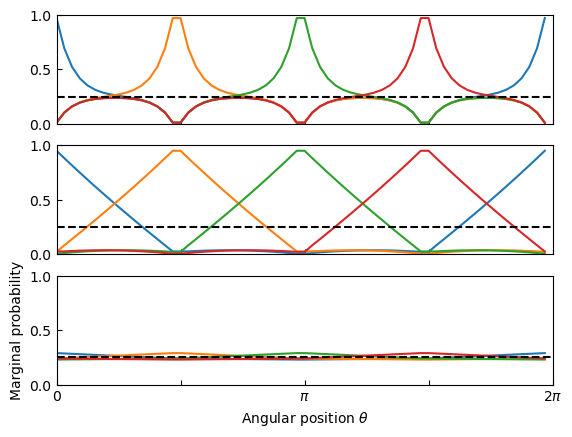

In [84]:
h = 6
M = 16
q = 4


plt.figure()
plt.subplot(3,1,1)
J = 2
ps = get_marginals_Potts(J, h, M, q)
plt.plot(np.arange(q*M)/(q*M)*2*np.pi, ps)
plt.ylim(0,1.)
plt.xlim(0,2*np.pi)
plt.axhline(1/q, color='k', linestyle='--')
plt.xticks(ticks=[0, np.pi/2, np.pi, 3*np.pi/2,2*np.pi], labels=['$0$', '', '$\\pi$', '', '$2\\pi$'])

plt.gca().set_xticklabels([])

plt.subplot(3,1,2)
J = 5
ps = get_marginals_Potts(J, h, M, q)
plt.plot(np.arange(q*M)/(q*M)*2*np.pi, ps)
plt.ylim(0,1.)
plt.xlim(0,2*np.pi)
plt.axhline(1/q, color='k', linestyle='--')
plt.xticks(ticks=[0, np.pi/2, np.pi, 3*np.pi/2,2*np.pi], labels=['$0$', '', '$\\pi$', '', '$2\\pi$'])
plt.xticks(ticks=[0, np.pi/2, np.pi, 3*np.pi/2,2*np.pi], labels=['$0$', '', '$\\pi$', '', '$2\\pi$'])
plt.gca().set_xticklabels([])
plt.subplot(3,1,3)
J = 8
ps = get_marginals_Potts(J, h, M, q)
plt.plot(np.arange(q*M)/(q*M)*2*np.pi, ps)
plt.ylim(0,1.)
plt.xlim(0,2*np.pi)
plt.xticks(ticks=[0, np.pi/2, np.pi, 3*np.pi/2,2*np.pi], labels=['$0$', '', '$\\pi$', '', '$2\\pi$'])
plt.axhline(1/q, color='k', linestyle='--')
plt.xlabel('Angular position $\\theta$')
plt.ylabel('Marginal probability')

plt.savefig('Potts_marginals_vs_pos.pdf')

### PI vs $\tilde{J}$ for varying $T$

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:28: RuntimeWarning: overflow encountered in matmul
  T = T @ Tqs[i] @ T_N
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:48: RuntimeWarning: overflow encountered in matmul
  T = T @ Tqs[i] @ T_M
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:66: RuntimeWarning: overflow encountered in matmul
  T = T @ Tqs[i] @ T_M
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:67: RuntimeWarning: invalid value encountered in scalar divide
  ps[k*M,n] = np.trace(T) / Z # the marginal at the k-th position in the block for state n
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:64: RuntimeWarning: overflow encountered in matmul
  T = T @ sQ[n] @ Tqs[i] @ T_M
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:77: RuntimeWarning: overflow encountered in matmul
  T = T @ Tqs[j] 

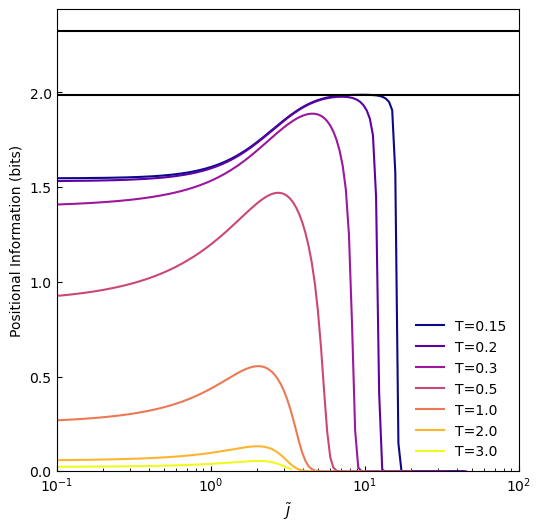

In [85]:
N_J = 150
Js = np.logspace(-2,np.log10(15),N_J)

q = 5
entropies = np.zeros(N_J)
for i, J in enumerate(Js):
    h = 10
    M = 16
    ps = get_marginals_Potts(J, h, M, q)
    entropies[i] = get_positionalInfo_Potts(ps, M, q)

Ts = [0.15, 0.2, 0.3, 0.5, 1.0, 2.0, 3.0]
colr = plt.cm.plasma(np.linspace(0, 1, len(Ts)))
plt.figure(figsize=(8, 6))

for j, T in enumerate(Ts):
    Js = np.logspace(-2,np.log10(10),N_J)

    entropies = np.zeros(N_J)
    for i, J in enumerate(Js):
        h = 3 / T
        M = 3
        ps = get_marginals_Potts(J/T, h, M, q)
        entropies[i] = get_positionalInfo_Potts(ps, M, q)
    plt.plot(Js/T, entropies, linestyle='-', color=colr[j], label=f'T={T}')
plt.xlabel(r'$\tilde{J}$')
plt.xlim(1e-1, 100)
plt.ylim(0, 1.05*np.log2(q))
plt.axhline(np.log2(q), color='k')
p_ = np.linspace(0,1,M)
s = 2/(M) *np.sum( xlogy(p_, p_))/np.log(2)
plt.axhline(np.log2(q)+s, color='k')
plt.xscale('log')
plt.ylabel('Positional Information (bits)')
plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
plt.savefig('Potts_PI_D_varT_N3_h3.pdf')

### PI vs $J,h$

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/2375234998.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


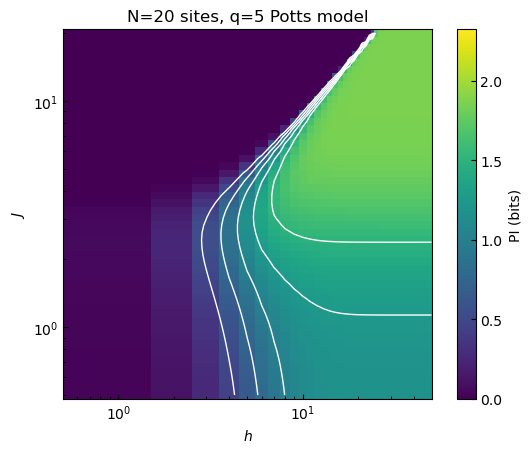

In [86]:
plt.figure()

N_J = 50
N_h = 50

Hs = np.linspace(1, 50, N_h)
entropies_arr = np.zeros((N_J, N_h))
for j, h in enumerate(Hs):
    Js = np.logspace(-0.3,np.log10(20),N_J)
    for i, J in enumerate(Js):
        M = 4
        q = 5
        ps = get_marginals_Potts(J, h, M, q)
        entropies_arr[i,j] = get_positionalInfo_Potts(ps, M, q)
plt.pcolormesh(Hs, Js, entropies_arr[:,:],  shading='nearest', cmap='viridis', vmin=0, vmax=np.log2(q))
plt.colorbar(label='PI (bits)')
plt.contour(Hs, Js, entropies_arr[:,:], levels=[0.5, 0.75, 1, 1.25, 1.5], colors='w', linewidths=1)
plt.xlabel('$h$')
plt.ylabel('$J$')

plt.yscale('log')
plt.xscale('log')

plt.legend(frameon=False)
plt.gca().set_box_aspect(1)
plt.title('N=20 sites, q=5 Potts model')
plt.savefig('Potts_PI_Dvh_N20_q5_contour.pdf')

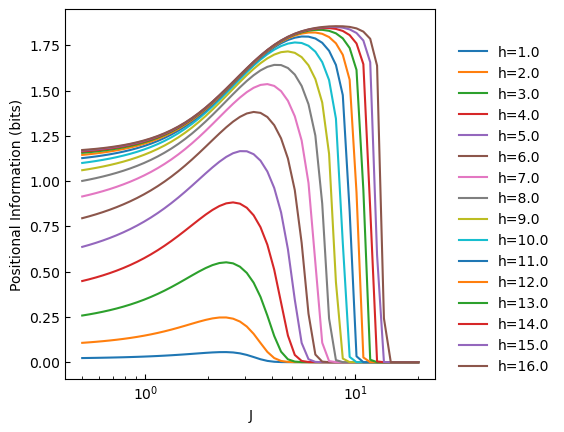

In [88]:
# slices plot above for different h
plt.figure()
for k in range(len(Hs)//3):
    plt.plot(Js, entropies_arr[:,k])
plt.xscale('log')
plt.xlabel('J')
plt.ylabel('Positional Information (bits)')
plt.gca().set_box_aspect(1)
plt.legend([f'h={Hs[i]:.1f}' for i in range(len(Hs)//3)], frameon=False,loc=(1.05, 0))


### PI bound as a function of $N$ and $q$

In [89]:
# compute maximal PI for varying N = q * M , here q = 3
Ms = np.arange(2, 40, 2)
maxes_PI = np.zeros(len(Ms))
N_J = 40
N_h = 40
q = 3
# sweep parameters
Js = np.logspace(-1,np.log10(1000),N_J)
Hs = np.linspace(0, 30, N_h)
for k, m in tqdm.tqdm(enumerate(Ms)):
    entropies_arr = np.zeros((N_J, N_h))
    for j, h in enumerate(Hs):
        Js = np.logspace(-2,np.log10(10),N_J)
        for i, J in enumerate(Js):
            #h = h / T
            M = m
            ps = get_marginals_Potts(J, h, M, q)
            #print(ps.shape)
            entropies_arr[i,j] = get_positionalInfo_Potts(ps, M, q)
    m_PI = np.max(entropies_arr[np.logical_not(np.isnan(entropies_arr))])
    print(m_PI)
    maxes_PI[k] = np.max(entropies_arr)

1it [00:00,  3.04it/s]

1.5849554226331215


2it [00:00,  2.14it/s]

1.125580693270408


3it [00:01,  1.57it/s]

...

/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:75: RuntimeWarning: invalid value encountered in matmul
  T = T @  Tqs[j] @ block_T
16it [00:39,  4.11s/it]/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/3582696230.py:64: RuntimeWarning: invalid value encountered in matmul
  T = T @ sQ[n] @ Tqs[i] @ T_M
17it [00:45,  4.45s/it]

0.7951250298638776


18it [00:50,  4.80s/it]

0.789429280745859
0.7839090983820614


19it [00:56,  2.98s/it]


0 0.0
1.0
1 -0.4591479170272447
0.5408520829727552
2 -0.5642928964473436
0.4357071035526564
3 -0.6100053707958025
0.3899946292041975
4 -0.6353669470353955
0.36463305296460446
5 -0.6514294792100979
0.34857052078990214
6 -0.6624901846610567
0.3375098153389433
7 -0.6705594673617065
0.32944053263829354
8 -0.676700725623717
0.32329927437628303
9 -0.6815281635895699
0.3184718364104301
10 -0.6854208675910366
0.3145791324089634
11 -0.6886252718262302
0.31137472817376977
12 -0.6913084063612728
0.3086915936387272
13 -0.6935874364506274
0.30641256354937263
14 -0.6955469456660401
0.30445305433395986
15 -0.697249505939264
0.30275049406073595
16 -0.6987423886189809
0.30125761138101914
17 -0.7000619643411102
0.29993803565888977
18 -0.7012366690135533
0.2987633309864467


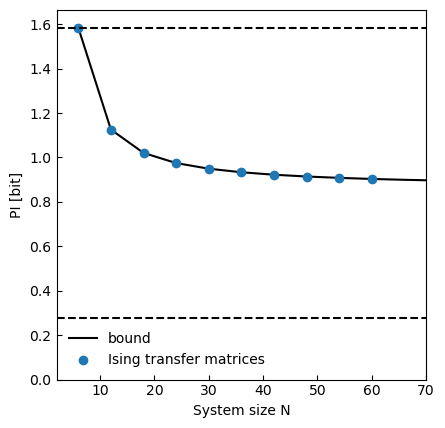

In [90]:
from scipy.special import xlogy
plt.figure()
Ms = np.arange(2, 40, 2)
bound_n = np.ones(len(Ms))
for i,m in enumerate(Ms):
    p_ = np.linspace(0,1,m)
    s = 2/(m) *np.sum( xlogy(p_, p_))/np.log(2)
    print(i,s)
    print(1+s)
    bound_n[i] = np.log2(q)+s

plt.plot(q*Ms, bound_n, color='k', zorder=-1, label='bound')
plt.scatter(q*Ms, maxes_PI, label='Ising transfer matrices')
plt.axhline(1-0.5/np.log(2), color='k', linestyle='--')
plt.axhline(np.log2(q), color='k', linestyle='--')

plt.legend(frameon=False)

x = np.linspace(2, 100)

plt.xlabel('System size N')
plt.ylabel('PI [bit]')
plt.xlim(left=2, right=70) #np.max(Ns))
plt.ylim(0, 1.05*np.log2(q))

plt.gca().set_box_aspect(1)

In [ ]:
# now vary q as well - should take ~ 12 min to run on a laptop
Ms = np.arange(2, 40, 2)
Q = 6
maxes_PI = [np.zeros(len(Ms)) for _ in range(2,Q+1)]
N_J = 40
N_h = 40

Qs = np.arange(2,Q+1)
Js = np.logspace(-1,np.log10(1000),N_J)
Hs = np.linspace(0, 30, N_h)
for idx, q in enumerate(Qs):
    for k, m in tqdm.tqdm(enumerate(Ms)):
        entropies_arr = np.zeros((N_J, N_h))
        for j, h in enumerate(Hs):
            Js = np.logspace(-2,np.log10(10),N_J)
            for i, J in enumerate(Js):
                M = m
                ps = get_marginals_Potts(J, h, M, q)
                entropies_arr[i,j] = get_positionalInfo_Potts(ps, M, q)
        m_PI = np.max(entropies_arr[np.logical_not(np.isnan(entropies_arr))])
        print(m_PI)
        maxes_PI[idx][k] = np.max(entropies_arr)

0it [00:00, ?it/s]

0.9999929388219194

1it [00:00,  4.83it/s]

2it [00:00,  3.99it/s]

0.5408505671830582


...

0.33363280968660564


18it [04:21, 24.35s/it]

0.3022132587030795


19it [04:50, 15.29s/it]

0.2261934325779173


2
3
4
5
6


/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/2804748993.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


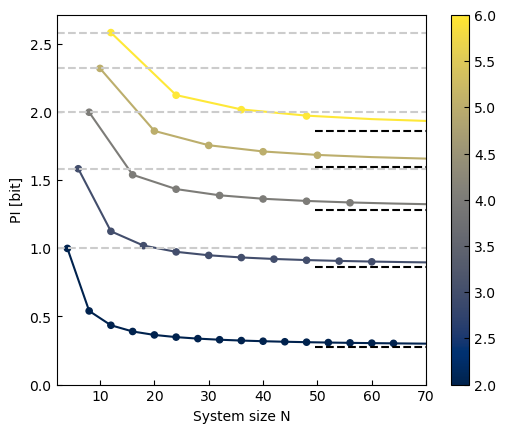

In [92]:
from scipy.special import xlogy
plt.figure()
Ns = np.arange(2, 100)
Ms = np.arange(2, 40, 2)

for idx, q in enumerate(Qs):
    bound_n = np.ones(len(Ms))
    print(q)
    # sawtooth profile
    for i,m in enumerate(Ms):
        p_ = np.linspace(0,1,m)
        s = 2/(m) *np.sum( xlogy(p_, p_))/np.log(2)
        bound_n[i] = np.log2(q)+s

    sc = plt.scatter(q*Ms, maxes_PI[idx], s=20, c=q*np.ones(len(maxes_PI[idx])),cmap='cividis', vmin=2, vmax=Q)
    plt.plot(q*Ms, bound_n, color=sc.to_rgba(q), zorder=-1)
    plt.axhline(np.log2(q)-0.5/np.log(2), xmin=0.7,color='k', linestyle='--')
    plt.legend(frameon=False)
    x = np.linspace(2, 100)
    plt.axhline(np.log2(q), color=[0.8,0.8,0.8], linestyle='--')
plt.colorbar()
plt.xlabel('System size N')
plt.ylabel('PI [bit]')
plt.xlim(left=2, right=70)#np.max(Ns) )
plt.ylim(0, 1.05*np.log2(q))

plt.gca().set_box_aspect(1)

plt.savefig('potts_bound_absolute.pdf')

2
3
4
5
6


/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/1403248687.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc = plt.scatter(q*Ms, maxes_PI[idx]/np.log2(q), s=20, c=q*np.ones(len(maxes_PI[idx])),cmap=plt.cm.get_cmap('cividis', len(Qs)), vmin=2, vmax=Q)
/var/folders/yv/gp5ryv054ts0ppkn51lbb3tm0000gn/T/ipykernel_19931/1403248687.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


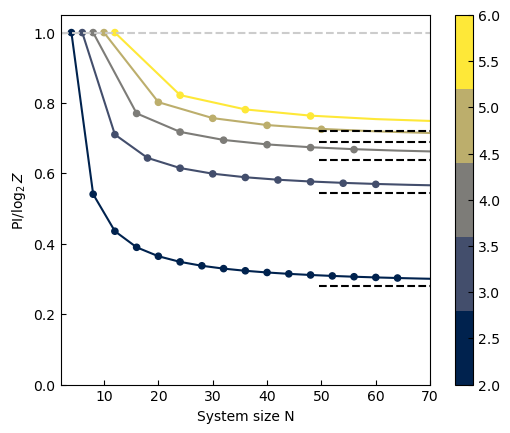

In [93]:
from scipy.special import xlogy
plt.figure()
Ns = np.arange(2, 100)
Ms = np.arange(2, 40, 2)

for idx, q in enumerate(Qs):
    bound_n = np.ones(len(Ms))
    print(q)
    for i,m in enumerate(Ms):
        p_ = np.linspace(0,1,m)
        s = 2/(m) *np.sum( xlogy(p_, p_))/np.log(2)
        bound_n[i] = np.log2(q)+s
    sc = plt.scatter(q*Ms, maxes_PI[idx]/np.log2(q), s=20, c=q*np.ones(len(maxes_PI[idx])),cmap=plt.cm.get_cmap('cividis', len(Qs)), vmin=2, vmax=Q)
    plt.plot(q*Ms, bound_n/np.log2(q), color=sc.to_rgba(q), zorder=-1)
    plt.axhline((np.log2(q)-0.5/np.log(2))/np.log2(q), xmin=0.7,color='k', linestyle='--')
    plt.legend(frameon=False)
    x = np.linspace(2, 100)
plt.colorbar()
plt.axhline(1, color=[0.8,0.8,0.8], linestyle='--')
plt.xlabel('System size N')
plt.ylabel('PI/$\\log_2Z$')
plt.xlim(left=2, right=70)#np.max(Ns) )
plt.ylim(0, 1.05)

plt.gca().set_box_aspect(1)
plt.savefig('potts_bound_relative.pdf')